In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from braindecode.models import EEGNet
import copy
import random
import pandas as pd
from tqdm import notebook
import tqdm
from pathlib import Path
import seaborn as sns
import scipy

torch.cuda.is_available()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.get_device_name(0)

'NVIDIA RTX 3000 Ada Generation Laptop GPU'

# Utility functions

In [4]:
import sys
sys.path.insert(0, str(Path.cwd().parent))

from cross_subject_utils import (
    plot_learning_curves,
    evaluate,
    load_data_from_users,
)

In [5]:
def train(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=100,
    device=0,
    save_path="best_model.pth",
):
    best_val_accuracy = -float("inf")
    model.to(device)
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    for epoch in tqdm.notebook.tqdm(range(num_epochs)):
        # Training Phase
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            # eval train
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_accuracy = train_correct / train_total
        avg_train_loss = running_loss / len(train_loader)

        # eval validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.inference_mode():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # val accuracy
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_accuracy = val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Save if best vall acc
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            # print(f"Best model saved with accuracy: {best_val_accuracy:.4f}")

        print(
            f"Epoch {epoch + 1}/{num_epochs}: "
            f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}"
        )
    plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies)
    model.load_state_dict(best_model)
    return model

# Leave-one-user-out Cross Validation

Deixa um usuário de fora e treina em todos os outros

In [7]:
frequencias_e_fases = scipy.io.loadmat(
    "/home/mateuschinelatto/Experiments/data/benchmark/Freq_Phase.mat"
)
frequencias = frequencias_e_fases["freqs"]
frequencias = np.round(frequencias, 2).ravel()
fases = frequencias_e_fases["phases"]

# Parâmetros de filtragem
filter_order = 10
freq_cut_high = 50
freq_cut_low = 6

# Parâmetros de pré-processamento
sample_rate = 250
delay = 160  # 160 amostras, 0,5s (sem estimulação) + 0,14s (latencia para começo da evocação)

# Parâmetros de janelas e sessões
tamanho_da_janela_seg = 1
tamanho_da_janela = int(np.ceil(tamanho_da_janela_seg * sample_rate))

# Eletrodos e frequências de interesse
occipital_electrodes = np.array([47, 53, 54, 55, 56, 57, 60, 61, 62])
frequencias_desejadas = frequencias[:8]
indices = [np.where(frequencias == freq)[0][0] for freq in frequencias_desejadas]

# Usuários
# users = list(range(1, 36))  # Usuários de 1 a 35
users = list(range(1, 11))  # Usuários de 1 a 10

epochs = 1000
exp_dir = Path(
    f"10_8/EEGNET_nb/{len(users)}_users_{len(frequencias_desejadas)}_freqs_{tamanho_da_janela_seg}_s/"
)

In [8]:
print("Usuários de interesse:", users)
print("Frequências de interesse:", frequencias_desejadas)
print("Indices das frequências de interesse:", indices)

Usuários de interesse: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Frequências de interesse: [ 8.  9. 10. 11. 12. 13. 14. 15.]
Indices das frequências de interesse: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [9]:
all_data = load_data_from_users(
    dataset_path="/home/mateuschinelatto/Experiments/data/benchmark/",
    users=users,
    visual_delay=delay,
    filter_bandpass=True,
    sample_rate=sample_rate,
    freq_cut_low=freq_cut_low,
    freq_cut_high=freq_cut_high,
    filter_order=filter_order,
)

Carregando dados dos usuários: 100%|██████████| 10/10 [00:32<00:00,  3.26s/it]


Processando Usuário 1
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0883, Train Accuracy: 0.1335, Val Loss: 2.0699, Val Accuracy: 0.1538
Epoch 2/1000: Train Loss: 2.0913, Train Accuracy: 0.1444, Val Loss: 2.0650, Val Accuracy: 0.2000
Epoch 3/1000: Train Loss: 2.0578, Train Accuracy: 0.1935, Val Loss: 2.0610, Val Accuracy: 0.2154
Epoch 4/1000: Train Loss: 2.0470, Train Accuracy: 0.1689, Val Loss: 2.0590, Val Accuracy: 0.2308
Epoch 5/1000: Train Loss: 2.0392, Train Accuracy: 0.1744, Val Loss: 2.0568, Val Accuracy: 0.2462
Epoch 6/1000: Train Loss: 2.0319, Train Accuracy: 0.2071, Val Loss: 2.0541, Val Accuracy: 0.2308
Epoch 7/1000: Train Loss: 2.0024, Train Accuracy: 0.2589, Val Loss: 2.0507, Val Accuracy: 0.2308
Epoch 8/1000: Train Loss: 2.0012, Train Accuracy: 0.2534, Val Loss: 2.0482, Val Accuracy: 0.2308
Epoch 9/1000: Train Loss: 1.9885, Train Accuracy: 0.2779, Val Loss: 2.0457, Val Accuracy: 0.2462
Epoch 10/1000: Train Loss: 1.9729, Train Accuracy: 0.2943, Val Loss: 2.0428, Val Accuracy: 0.2769
Epoch 11/1000: Train Loss: 1.

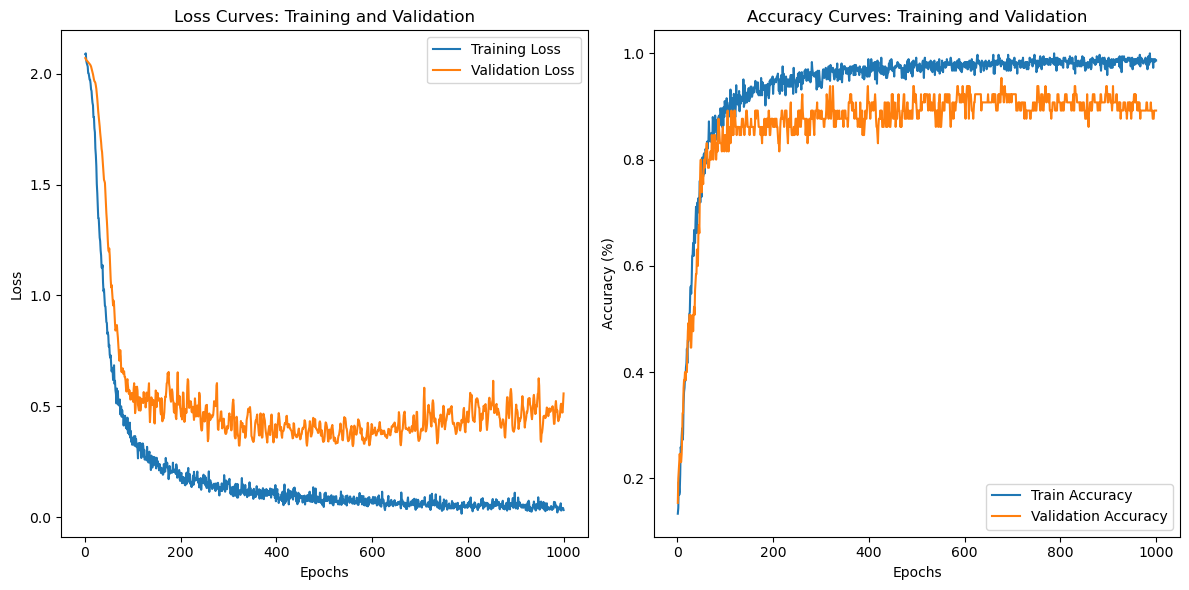

Usuário 1 Finalizado: Acurácia=0.7917, Recall=0.7917, F1=0.7757
--------------------------------------------------
Processando Usuário 2
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0857, Train Accuracy: 0.1499, Val Loss: 2.0799, Val Accuracy: 0.1077
Epoch 2/1000: Train Loss: 2.0634, Train Accuracy: 0.1444, Val Loss: 2.0795, Val Accuracy: 0.0923
Epoch 3/1000: Train Loss: 2.0492, Train Accuracy: 0.1744, Val Loss: 2.0791, Val Accuracy: 0.1077
Epoch 4/1000: Train Loss: 2.0531, Train Accuracy: 0.1853, Val Loss: 2.0788, Val Accuracy: 0.1231
Epoch 5/1000: Train Loss: 2.0256, Train Accuracy: 0.2371, Val Loss: 2.0778, Val Accuracy: 0.1385
Epoch 6/1000: Train Loss: 2.0168, Train Accuracy: 0.2180, Val Loss: 2.0760, Val Accuracy: 0.1846
Epoch 7/1000: Train Loss: 2.0059, Train Accuracy: 0.2452, Val Loss: 2.0734, Val Accuracy: 0.1846
Epoch 8/1000: Train Loss: 1.9943, Train Accuracy: 0.2425, Val Loss: 2.0709, Val Accuracy: 0.2000
Epoch 9/1000: Train Loss: 1.9733, Train Accuracy: 0.2997, Val Loss: 2.0677, Val Accuracy: 0.1846
Epoch 10/1000: Train Loss: 1.9589, Train Accuracy: 0.2834, Val Loss: 2.0638, Val Accuracy: 0.2154
Epoch 11/1000: Train Loss: 1.

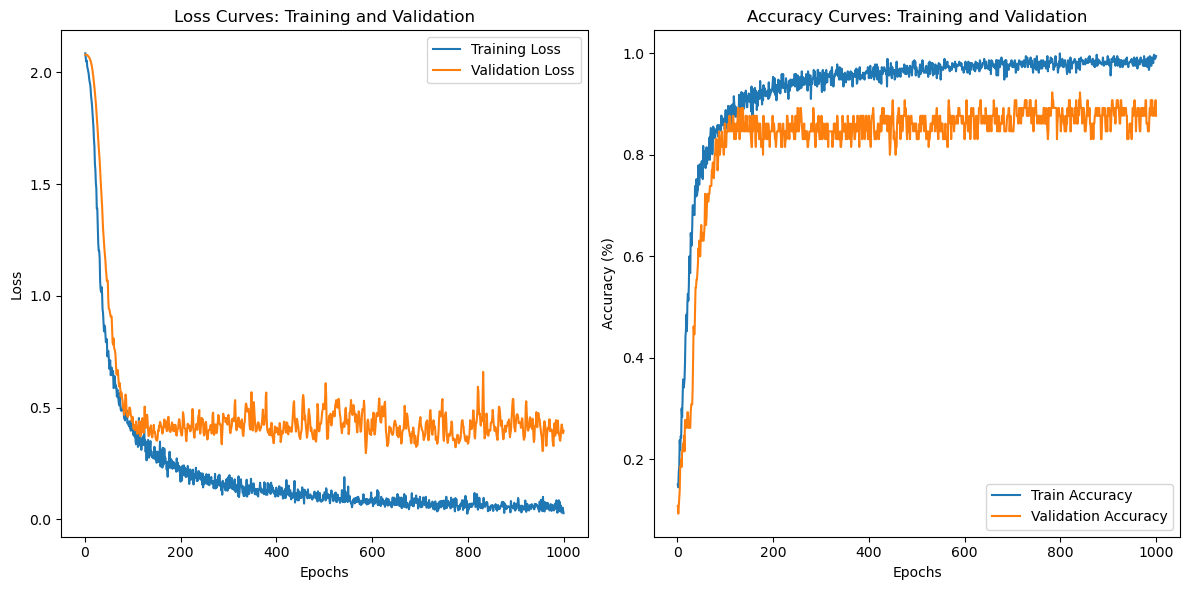

Usuário 2 Finalizado: Acurácia=0.7083, Recall=0.7083, F1=0.7136
--------------------------------------------------
Processando Usuário 3
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0950, Train Accuracy: 0.1308, Val Loss: 2.0761, Val Accuracy: 0.1538
Epoch 2/1000: Train Loss: 2.0664, Train Accuracy: 0.1717, Val Loss: 2.0752, Val Accuracy: 0.1385
Epoch 3/1000: Train Loss: 2.0578, Train Accuracy: 0.1526, Val Loss: 2.0746, Val Accuracy: 0.1692
Epoch 4/1000: Train Loss: 2.0462, Train Accuracy: 0.1826, Val Loss: 2.0739, Val Accuracy: 0.1538
Epoch 5/1000: Train Loss: 2.0241, Train Accuracy: 0.2561, Val Loss: 2.0735, Val Accuracy: 0.2000
Epoch 6/1000: Train Loss: 2.0168, Train Accuracy: 0.2316, Val Loss: 2.0731, Val Accuracy: 0.2154
Epoch 7/1000: Train Loss: 1.9921, Train Accuracy: 0.2970, Val Loss: 2.0720, Val Accuracy: 0.2154
Epoch 8/1000: Train Loss: 1.9922, Train Accuracy: 0.2888, Val Loss: 2.0706, Val Accuracy: 0.2308
Epoch 9/1000: Train Loss: 1.9780, Train Accuracy: 0.3079, Val Loss: 2.0695, Val Accuracy: 0.2615
Epoch 10/1000: Train Loss: 1.9551, Train Accuracy: 0.3515, Val Loss: 2.0679, Val Accuracy: 0.2769
Epoch 11/1000: Train Loss: 1.

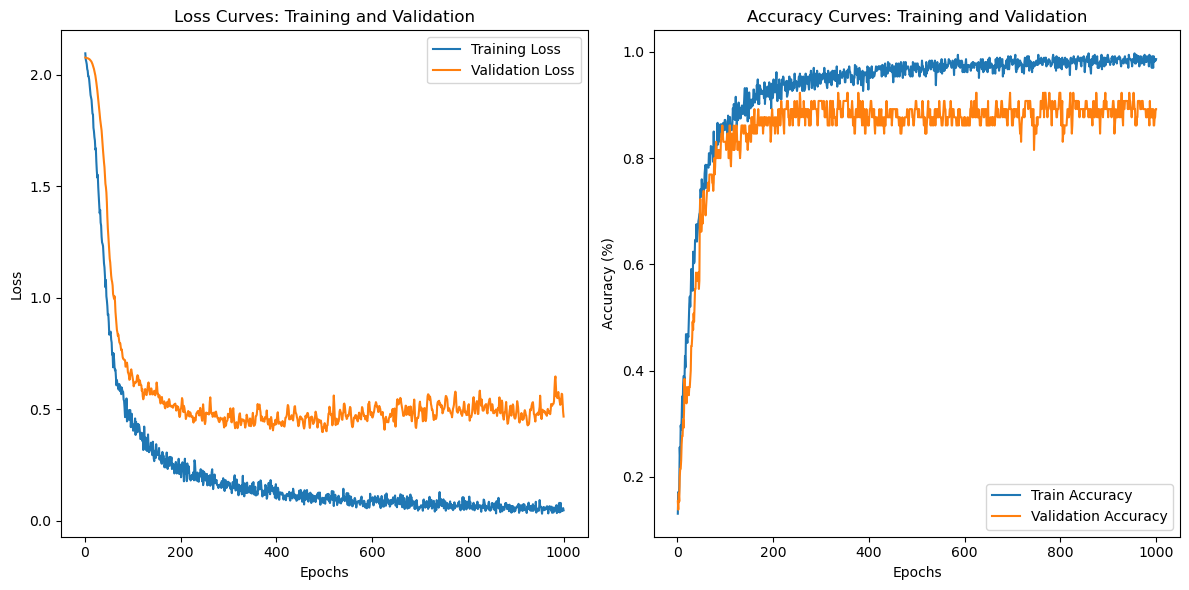

Usuário 3 Finalizado: Acurácia=1.0000, Recall=1.0000, F1=1.0000
--------------------------------------------------
Processando Usuário 4
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0965, Train Accuracy: 0.1281, Val Loss: 2.0802, Val Accuracy: 0.1077
Epoch 2/1000: Train Loss: 2.0635, Train Accuracy: 0.1526, Val Loss: 2.0793, Val Accuracy: 0.1231
Epoch 3/1000: Train Loss: 2.0467, Train Accuracy: 0.1853, Val Loss: 2.0782, Val Accuracy: 0.1077
Epoch 4/1000: Train Loss: 2.0392, Train Accuracy: 0.2044, Val Loss: 2.0766, Val Accuracy: 0.1538
Epoch 5/1000: Train Loss: 2.0133, Train Accuracy: 0.2507, Val Loss: 2.0756, Val Accuracy: 0.1692
Epoch 6/1000: Train Loss: 2.0204, Train Accuracy: 0.2234, Val Loss: 2.0740, Val Accuracy: 0.2154
Epoch 7/1000: Train Loss: 1.9920, Train Accuracy: 0.2888, Val Loss: 2.0725, Val Accuracy: 0.2769
Epoch 8/1000: Train Loss: 1.9830, Train Accuracy: 0.2997, Val Loss: 2.0710, Val Accuracy: 0.2769
Epoch 9/1000: Train Loss: 1.9727, Train Accuracy: 0.2916, Val Loss: 2.0687, Val Accuracy: 0.2769
Epoch 10/1000: Train Loss: 1.9597, Train Accuracy: 0.3569, Val Loss: 2.0665, Val Accuracy: 0.3231
Epoch 11/1000: Train Loss: 1.

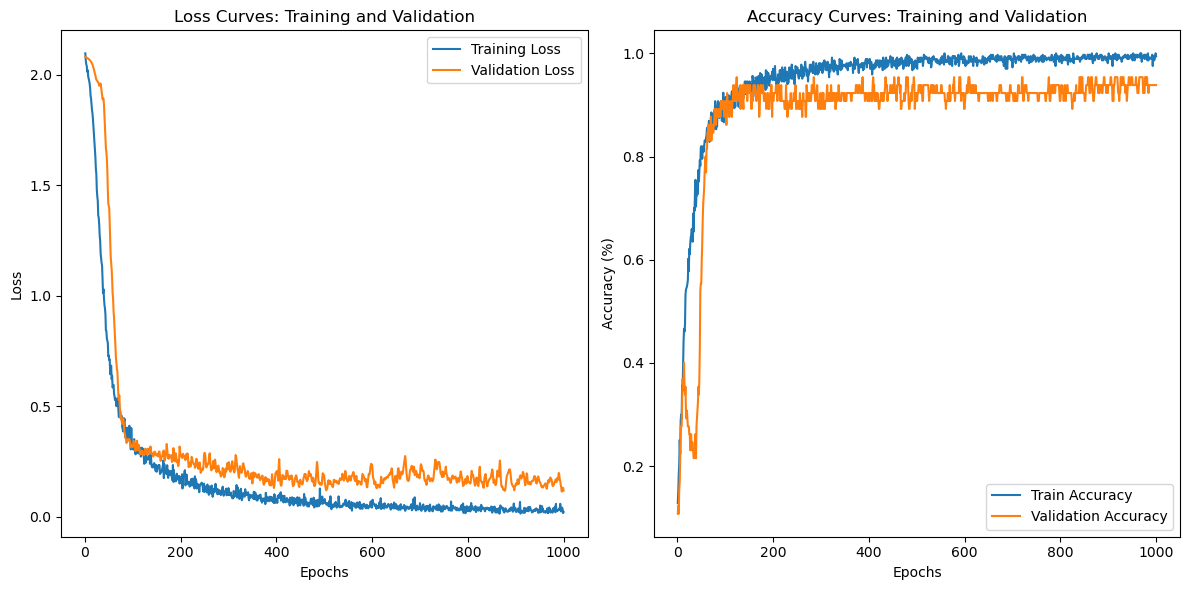

Usuário 4 Finalizado: Acurácia=0.3125, Recall=0.3125, F1=0.2538
--------------------------------------------------
Processando Usuário 5
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.1074, Train Accuracy: 0.1335, Val Loss: 2.0809, Val Accuracy: 0.1692
Epoch 2/1000: Train Loss: 2.0806, Train Accuracy: 0.1390, Val Loss: 2.0767, Val Accuracy: 0.1846
Epoch 3/1000: Train Loss: 2.0556, Train Accuracy: 0.1771, Val Loss: 2.0733, Val Accuracy: 0.1846
Epoch 4/1000: Train Loss: 2.0524, Train Accuracy: 0.1935, Val Loss: 2.0700, Val Accuracy: 0.2154
Epoch 5/1000: Train Loss: 2.0239, Train Accuracy: 0.2207, Val Loss: 2.0669, Val Accuracy: 0.2154
Epoch 6/1000: Train Loss: 2.0183, Train Accuracy: 0.2316, Val Loss: 2.0640, Val Accuracy: 0.2308
Epoch 7/1000: Train Loss: 1.9725, Train Accuracy: 0.3161, Val Loss: 2.0613, Val Accuracy: 0.2615
Epoch 8/1000: Train Loss: 1.9840, Train Accuracy: 0.2834, Val Loss: 2.0585, Val Accuracy: 0.3077
Epoch 9/1000: Train Loss: 1.9528, Train Accuracy: 0.3106, Val Loss: 2.0552, Val Accuracy: 0.2769
Epoch 10/1000: Train Loss: 1.9190, Train Accuracy: 0.3896, Val Loss: 2.0502, Val Accuracy: 0.3077
Epoch 11/1000: Train Loss: 1.

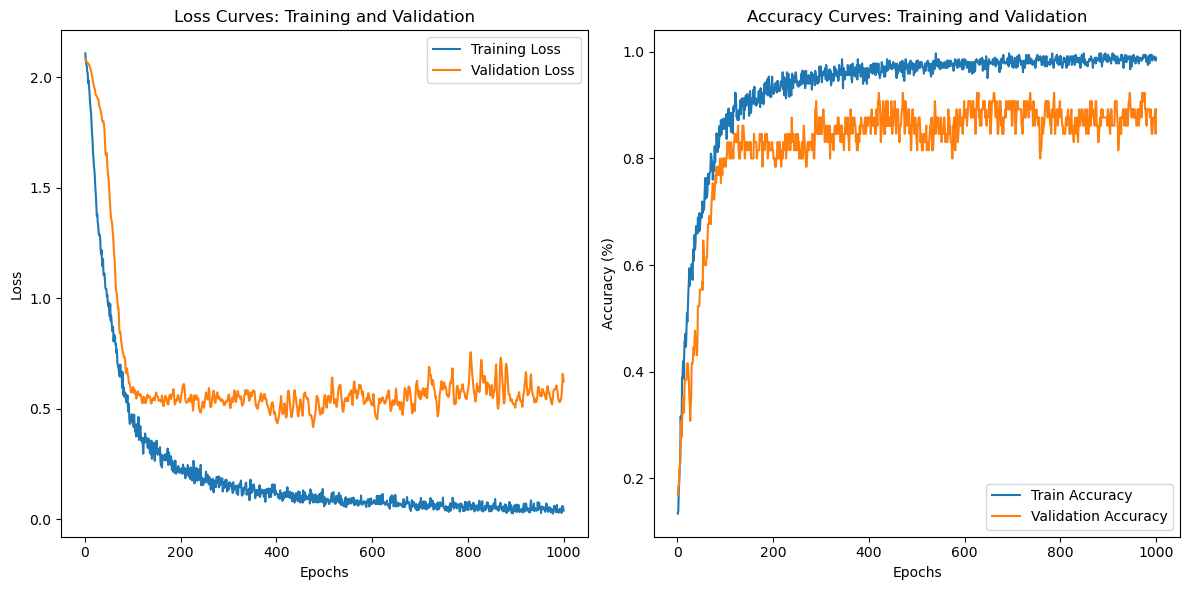

Usuário 5 Finalizado: Acurácia=0.9375, Recall=0.9375, F1=0.9384
--------------------------------------------------
Processando Usuário 6
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0887, Train Accuracy: 0.1199, Val Loss: 2.0785, Val Accuracy: 0.0923
Epoch 2/1000: Train Loss: 2.0724, Train Accuracy: 0.1608, Val Loss: 2.0763, Val Accuracy: 0.1231
Epoch 3/1000: Train Loss: 2.0503, Train Accuracy: 0.1771, Val Loss: 2.0741, Val Accuracy: 0.1385
Epoch 4/1000: Train Loss: 2.0414, Train Accuracy: 0.2098, Val Loss: 2.0718, Val Accuracy: 0.1538
Epoch 5/1000: Train Loss: 2.0230, Train Accuracy: 0.2343, Val Loss: 2.0696, Val Accuracy: 0.2000
Epoch 6/1000: Train Loss: 2.0135, Train Accuracy: 0.2534, Val Loss: 2.0673, Val Accuracy: 0.2308
Epoch 7/1000: Train Loss: 2.0044, Train Accuracy: 0.2452, Val Loss: 2.0651, Val Accuracy: 0.2615
Epoch 8/1000: Train Loss: 1.9908, Train Accuracy: 0.2916, Val Loss: 2.0621, Val Accuracy: 0.2769
Epoch 9/1000: Train Loss: 1.9726, Train Accuracy: 0.3297, Val Loss: 2.0593, Val Accuracy: 0.2769
Epoch 10/1000: Train Loss: 1.9589, Train Accuracy: 0.3079, Val Loss: 2.0563, Val Accuracy: 0.2923
Epoch 11/1000: Train Loss: 1.

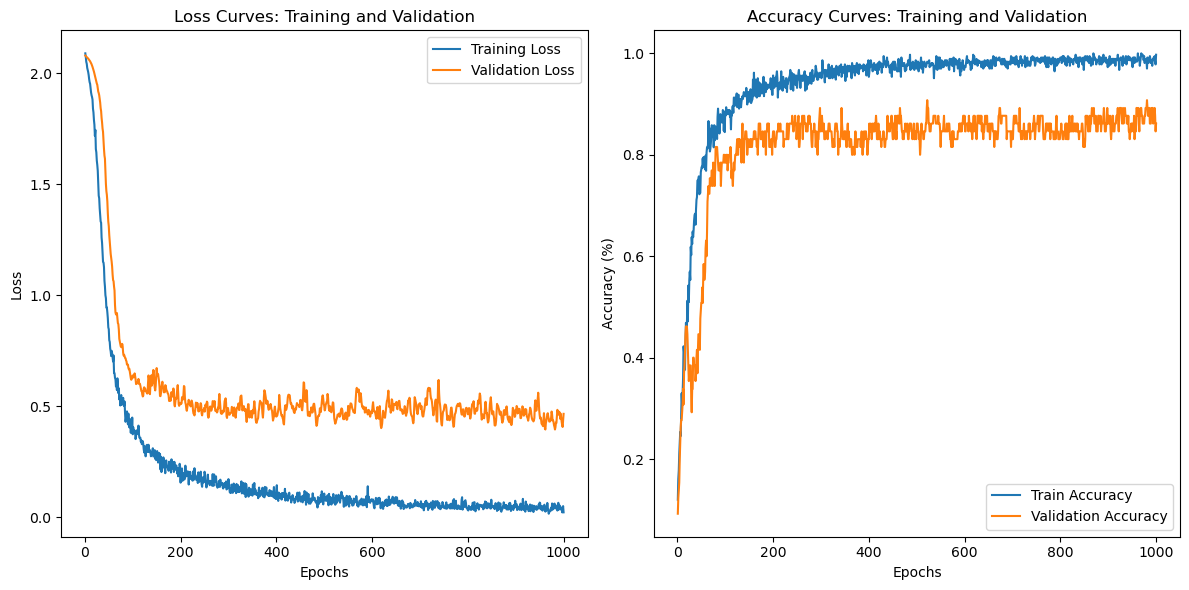

Usuário 6 Finalizado: Acurácia=0.7708, Recall=0.7708, F1=0.7549
--------------------------------------------------
Processando Usuário 7
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0821, Train Accuracy: 0.1308, Val Loss: 2.0792, Val Accuracy: 0.1538
Epoch 2/1000: Train Loss: 2.0654, Train Accuracy: 0.1499, Val Loss: 2.0780, Val Accuracy: 0.1077
Epoch 3/1000: Train Loss: 2.0453, Train Accuracy: 0.2180, Val Loss: 2.0768, Val Accuracy: 0.1385
Epoch 4/1000: Train Loss: 2.0411, Train Accuracy: 0.1907, Val Loss: 2.0756, Val Accuracy: 0.1538
Epoch 5/1000: Train Loss: 2.0093, Train Accuracy: 0.2616, Val Loss: 2.0744, Val Accuracy: 0.1385
Epoch 6/1000: Train Loss: 2.0142, Train Accuracy: 0.2452, Val Loss: 2.0730, Val Accuracy: 0.1538
Epoch 7/1000: Train Loss: 1.9929, Train Accuracy: 0.2861, Val Loss: 2.0711, Val Accuracy: 0.1538
Epoch 8/1000: Train Loss: 1.9786, Train Accuracy: 0.2997, Val Loss: 2.0693, Val Accuracy: 0.1692
Epoch 9/1000: Train Loss: 1.9720, Train Accuracy: 0.3215, Val Loss: 2.0670, Val Accuracy: 0.1692
Epoch 10/1000: Train Loss: 1.9487, Train Accuracy: 0.3379, Val Loss: 2.0647, Val Accuracy: 0.2000
Epoch 11/1000: Train Loss: 1.

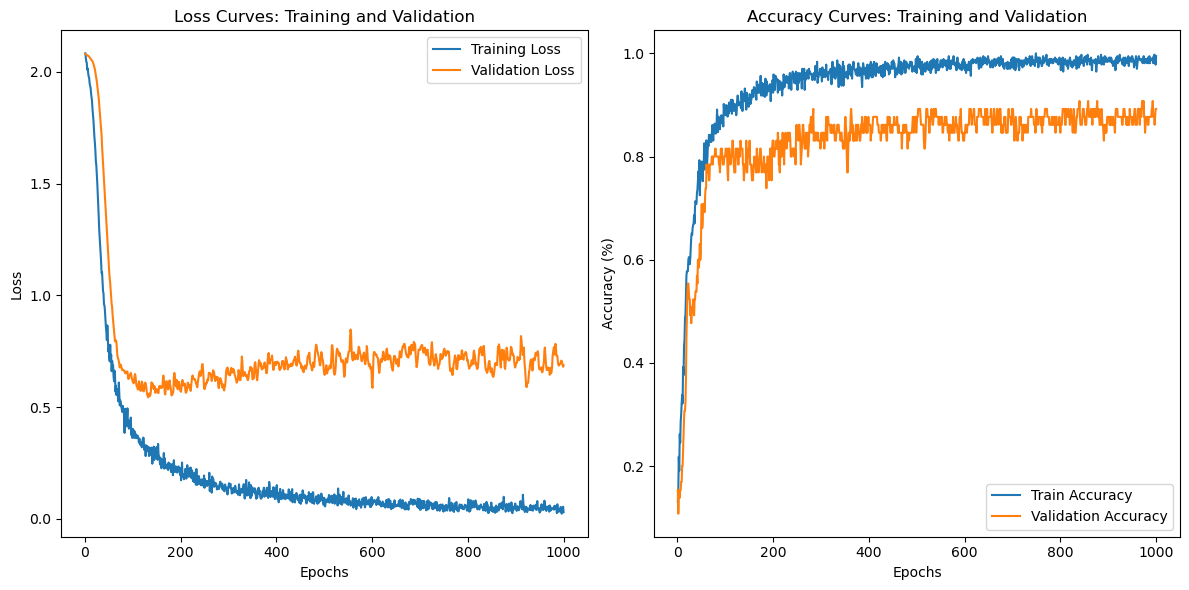

Usuário 7 Finalizado: Acurácia=0.7292, Recall=0.7292, F1=0.7107
--------------------------------------------------
Processando Usuário 8
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.1085, Train Accuracy: 0.1417, Val Loss: 2.0761, Val Accuracy: 0.1077
Epoch 2/1000: Train Loss: 2.0907, Train Accuracy: 0.1090, Val Loss: 2.0740, Val Accuracy: 0.1385
Epoch 3/1000: Train Loss: 2.0750, Train Accuracy: 0.1526, Val Loss: 2.0723, Val Accuracy: 0.1692
Epoch 4/1000: Train Loss: 2.0560, Train Accuracy: 0.1717, Val Loss: 2.0710, Val Accuracy: 0.1846
Epoch 5/1000: Train Loss: 2.0391, Train Accuracy: 0.1962, Val Loss: 2.0699, Val Accuracy: 0.1846
Epoch 6/1000: Train Loss: 2.0294, Train Accuracy: 0.1853, Val Loss: 2.0689, Val Accuracy: 0.2154
Epoch 7/1000: Train Loss: 2.0273, Train Accuracy: 0.2207, Val Loss: 2.0680, Val Accuracy: 0.2000
Epoch 8/1000: Train Loss: 1.9967, Train Accuracy: 0.2670, Val Loss: 2.0670, Val Accuracy: 0.2154
Epoch 9/1000: Train Loss: 1.9903, Train Accuracy: 0.2670, Val Loss: 2.0659, Val Accuracy: 0.2154
Epoch 10/1000: Train Loss: 1.9922, Train Accuracy: 0.2698, Val Loss: 2.0647, Val Accuracy: 0.2308
Epoch 11/1000: Train Loss: 1.

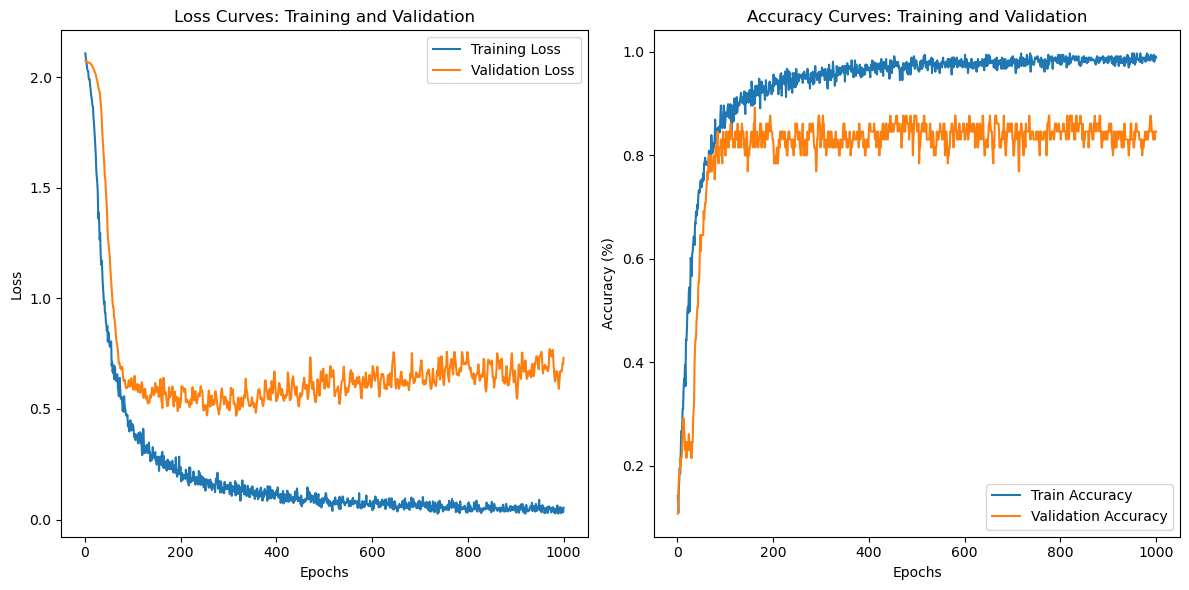

Usuário 8 Finalizado: Acurácia=0.8333, Recall=0.8333, F1=0.8328
--------------------------------------------------
Processando Usuário 9
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0926, Train Accuracy: 0.1335, Val Loss: 2.0729, Val Accuracy: 0.1538
Epoch 2/1000: Train Loss: 2.0698, Train Accuracy: 0.1580, Val Loss: 2.0714, Val Accuracy: 0.1692
Epoch 3/1000: Train Loss: 2.0541, Train Accuracy: 0.1717, Val Loss: 2.0698, Val Accuracy: 0.2000
Epoch 4/1000: Train Loss: 2.0432, Train Accuracy: 0.1962, Val Loss: 2.0682, Val Accuracy: 0.2000
Epoch 5/1000: Train Loss: 2.0305, Train Accuracy: 0.2125, Val Loss: 2.0667, Val Accuracy: 0.1692
Epoch 6/1000: Train Loss: 2.0211, Train Accuracy: 0.2098, Val Loss: 2.0653, Val Accuracy: 0.2154
Epoch 7/1000: Train Loss: 2.0007, Train Accuracy: 0.2807, Val Loss: 2.0636, Val Accuracy: 0.2000
Epoch 8/1000: Train Loss: 1.9760, Train Accuracy: 0.2888, Val Loss: 2.0609, Val Accuracy: 0.2462
Epoch 9/1000: Train Loss: 1.9797, Train Accuracy: 0.2452, Val Loss: 2.0577, Val Accuracy: 0.2462
Epoch 10/1000: Train Loss: 1.9540, Train Accuracy: 0.3052, Val Loss: 2.0545, Val Accuracy: 0.2769
Epoch 11/1000: Train Loss: 1.

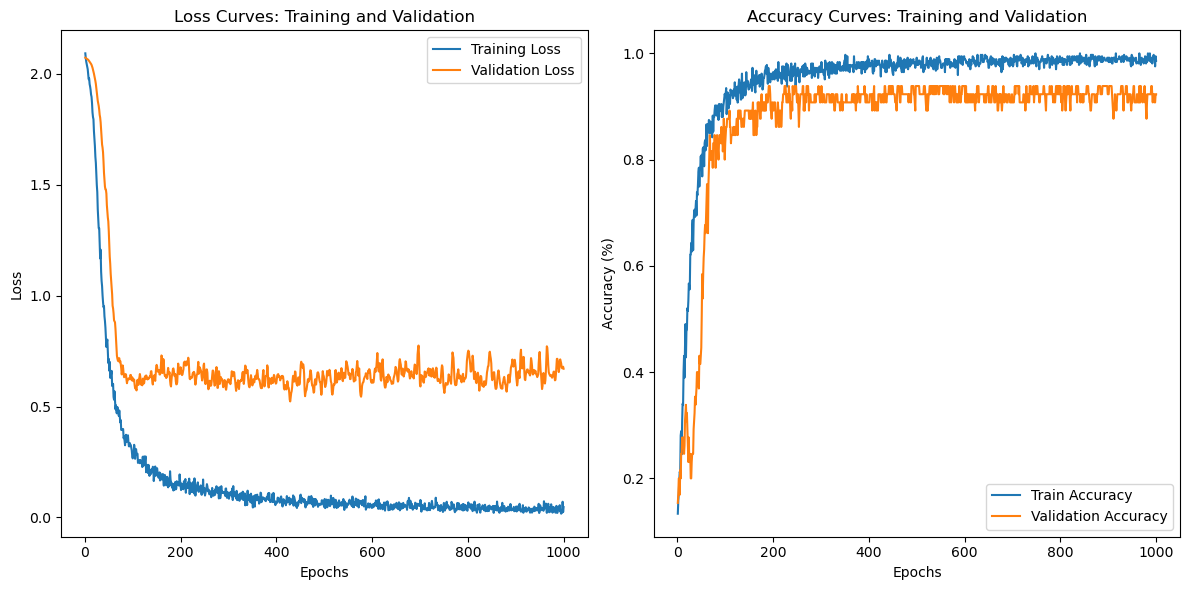

Usuário 9 Finalizado: Acurácia=0.4792, Recall=0.4792, F1=0.4456
--------------------------------------------------
Processando Usuário 10
X_train: torch.Size([432, 9, 250])
X_test: torch.Size([48, 9, 250])
Y_train: torch.Size([432])
Y_test: torch.Size([48])


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000: Train Loss: 2.0873, Train Accuracy: 0.1281, Val Loss: 2.0770, Val Accuracy: 0.1692
Epoch 2/1000: Train Loss: 2.0697, Train Accuracy: 0.1580, Val Loss: 2.0751, Val Accuracy: 0.1692
Epoch 3/1000: Train Loss: 2.0599, Train Accuracy: 0.1717, Val Loss: 2.0738, Val Accuracy: 0.1692
Epoch 4/1000: Train Loss: 2.0457, Train Accuracy: 0.1798, Val Loss: 2.0733, Val Accuracy: 0.2000
Epoch 5/1000: Train Loss: 2.0312, Train Accuracy: 0.2180, Val Loss: 2.0725, Val Accuracy: 0.2154
Epoch 6/1000: Train Loss: 2.0259, Train Accuracy: 0.2180, Val Loss: 2.0716, Val Accuracy: 0.2462
Epoch 7/1000: Train Loss: 2.0227, Train Accuracy: 0.2071, Val Loss: 2.0710, Val Accuracy: 0.2000
Epoch 8/1000: Train Loss: 2.0090, Train Accuracy: 0.2262, Val Loss: 2.0704, Val Accuracy: 0.1846
Epoch 9/1000: Train Loss: 1.9854, Train Accuracy: 0.2834, Val Loss: 2.0696, Val Accuracy: 0.1538
Epoch 10/1000: Train Loss: 1.9722, Train Accuracy: 0.2888, Val Loss: 2.0688, Val Accuracy: 0.1538
Epoch 11/1000: Train Loss: 1.

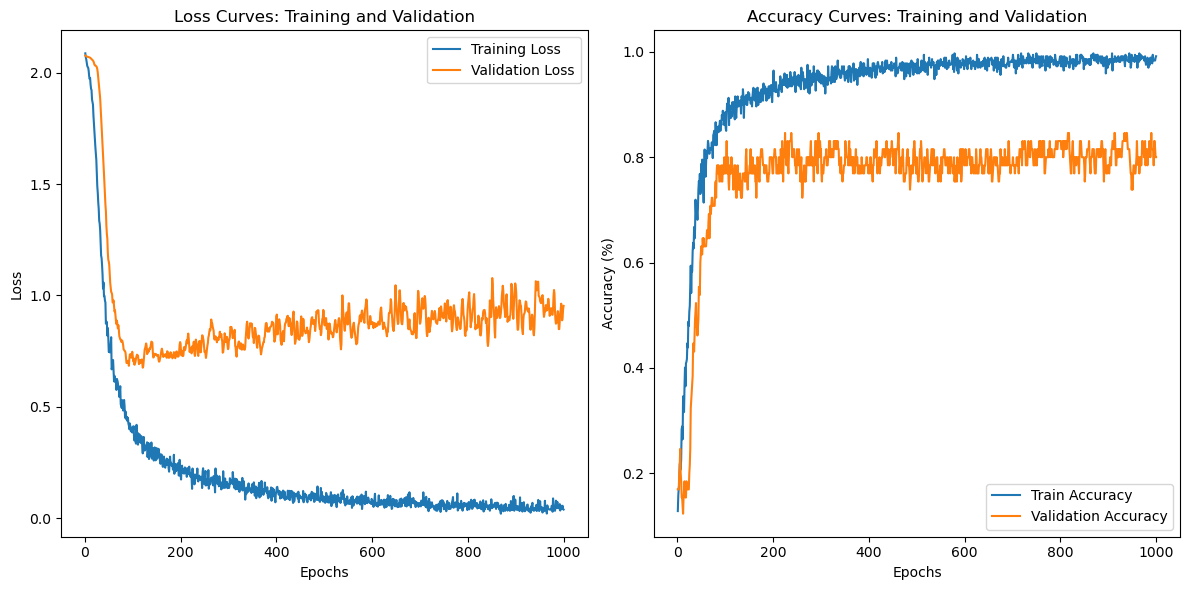

Usuário 10 Finalizado: Acurácia=0.7708, Recall=0.7708, F1=0.7582
--------------------------------------------------


In [11]:
seed = 42
torch.cuda.manual_seed(seed)
torch.manual_seed(seed)

# Lista para armazenar as métricas de todos os usuários
metricas_usuarios = []
exp_dir.mkdir(parents=True, exist_ok=True)

# Leave-one-user-out cross-validation
for user in range(1, len(all_data) + 1):
    print(f"Processando Usuário {user}")
    n_freqs_sel = len(indices)
    metricas_crossval = []
    users_train = [u for u in range(1, len(all_data) + 1) if u != user]
    user_test = user

    x_train = []
    labels_train = []
    x_test = []
    labels_test = []

    # Train data
    for u in users_train:
        data = all_data[u - 1]
        for session in range(data.shape[3]):
            for freq in range(len(indices)):
                eeg_trial = data[occipital_electrodes, :, indices[freq], session]
                eeg_trial = eeg_trial[:, :tamanho_da_janela]
                x_train.append(eeg_trial)
                labels_train.extend([frequencias[freq]])
    x_train = np.array(x_train)

    # Test data
    data = all_data[user_test - 1]
    for session in range(data.shape[3]):
        for freq in range(len(indices)):
            eeg_trial = data[occipital_electrodes, :, indices[freq], session]
            eeg_trial = eeg_trial[:, :tamanho_da_janela]
            x_test.append(eeg_trial)
            labels_test.extend([frequencias[freq]])
    x_test = np.array(x_test)

    # Mapeamento de rótulos
    mapeamento = {rotulo: i for i, rotulo in enumerate(sorted(frequencias_desejadas))}
    labels_train = torch.tensor([mapeamento[rotulo.item()] for rotulo in labels_train])
    labels_test = torch.tensor([mapeamento[rotulo.item()] for rotulo in labels_test])

    # Converter para tensores
    X_train = torch.from_numpy(x_train.copy()).float().to(device)
    X_test = torch.from_numpy(x_test.copy()).float().to(device)
    Y_train = labels_train.to(torch.long).to(device)
    Y_test = labels_test.to(torch.long).to(device)

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("Y_train:", Y_train.shape)
    print("Y_test:", Y_test.shape)

    # Configurar modelo e treinamento
    model = EEGNet(
        n_chans=9,
        n_outputs=len(frequencias_desejadas),
        n_times=tamanho_da_janela,
        kernel_length=(sample_rate // 2),
        F1=8,
        drop_prob=0.25,
    )
    model = model.to(device)

    dataset = TensorDataset(X_train, Y_train)
    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(seed),
    )

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
    test_loader = DataLoader(
        TensorDataset(X_test, Y_test), batch_size=10, shuffle=False
    )
    criterion = nn.CrossEntropyLoss()
    # optimizer = optim.Adam(model.parameters(), lr=0.0001)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1.5546306621573136e-05)

    # Treinar
    best_model = train(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=epochs,
        device=device,
        save_path=exp_dir.joinpath(f"best_model_user_{user}.pth"),
    )

    # Avaliar
    accuracy, recall, f1, cm = evaluate(best_model, test_loader)

    # Armazenar métricas
    metricas_crossval.append(
        {
            "usuario": user,
            "acuracia": accuracy,
            "recall": recall,
            "f1-score": f1,
            "confusion_matrix": cm,
        }
    )

    print(
        f"Usuário {user} Finalizado: Acurácia={accuracy:.4f}, Recall={recall:.4f}, F1={f1:.4f}"
    )

    # Salvar as métricas de cada usuário
    metricas_usuarios.extend(metricas_crossval)
    df_metricas = pd.DataFrame(metricas_usuarios)
    df_metricas.to_csv(exp_dir.joinpath("metricas.csv"), index=False)

    print("-" * 50)

# Leave one-session-out cross validation (DNN and TRCANet style)
Train a general model on 5 sessions, then from there fine-tune a model for each user using his 5 session again and validate on the sixth

In [ ]:
frequencias_e_fases = scipy.io.loadmat(
    "C:/Users/machi/Documents/Mestrado/repos/data/benchmark/Freq_Phase.mat"
)
frequencias = frequencias_e_fases["freqs"]
frequencias = np.round(frequencias, 2).ravel()
fases = frequencias_e_fases["phases"]

# Parâmetros de filtragem
filter_order = 10
freq_cut_high = 70
freq_cut_low = 6

# Parâmetros de pré-processamento
sample_rate = 250
delay = 160  # 160 amostras, 0,5s (sem estimulação) + 0,14s (latencia para começo da evocação)

# Parâmetros de janelas e sessões
tamanho_da_janela = 1
tamanho_da_janela = int(np.ceil(tamanho_da_janela * sample_rate))

# Eletrodos e frequências de interesse
occipital_electrodes = np.array([47, 53, 54, 55, 56, 57, 60, 61, 62])
frequencias_desejadas = frequencias[:]
indices = [np.where(frequencias == freq)[0][0] for freq in frequencias_desejadas]

epochs_general = 3
epochs_fine_tune = 2

exp_dir = Path("leave-one-session-out-10_freqs_1s-test")

In [ ]:
seed = 42
torch.cuda.manual_seed(seed)
torch.manual_seed(seed)

exp_dir.mkdir(parents=True, exist_ok=True)
general_models_dir = exp_dir.joinpath("general_models")
general_models_dir.mkdir(parents=True, exist_ok=True)
fine_tuned_models_dir = exp_dir.joinpath("fine_tuned_models")
fine_tuned_models_dir.mkdir(parents=True, exist_ok=True)

# Lista para armazenar as métricas de todos os usuários e sessões
metricas_usuarios = []

num_sessions = 6
num_users = len(all_data)

for sessao_teste in range(num_sessions):  # Leave-one-session-out
    print(f"Sessão de teste: {sessao_teste}")

    # 1. Treinar modelo geral em 5 sessões de todos os usuários
    x_train_general = []
    y_train_general = []

    for user in range(num_users):
        data = all_data[user]
        for sessao in range(num_sessions):
            if sessao == sessao_teste:
                continue
            for freq in range(len(indices)):
                eeg_trial = data[occipital_electrodes, :, indices[freq], sessao]
                eeg_trial = eeg_trial[:, :tamanho_da_janela]
                x_train_general.append(eeg_trial)
                y_train_general.extend([frequencias[freq]])
                # eeg_trial_janelas, numero_janelas = separar_em_janelas(
                #     eeg_trial.T, tamanho_da_janela
                # )
                # eeg_trial_janelas_array = np.stack(eeg_trial_janelas).transpose(0, 2, 1)
                # x_train_general.append(eeg_trial_janelas_array)
                # y_train_general.extend([frequencias[freq]] * numero_janelas)

    # x_train_general = np.concatenate(x_train_general, axis=0)
    x_train_general = np.array(x_train_general)

    # Mapeamento de rótulos
    mapeamento = {rotulo: i for i, rotulo in enumerate(sorted(frequencias_desejadas))}
    y_train_general_tensor = torch.tensor(
        [mapeamento[rotulo.item()] for rotulo in y_train_general]
    )

    X_train_general = torch.from_numpy(x_train_general.copy()).float().to(device)
    Y_train_general = y_train_general_tensor.to(torch.long).to(device)

    # Treinar modelo geral
    model_general = EEGNetv4(
        n_chans=9,
        n_outputs=len(frequencias_desejadas),
        n_times=tamanho_da_janela,
        kernel_length=(tamanho_da_janela // 2),
    ).to(device)

    dataset_general = TensorDataset(X_train_general, Y_train_general)
    train_size = int(0.85 * len(dataset_general))
    val_size = len(dataset_general) - train_size
    train_dataset, val_dataset = random_split(
        dataset_general,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(seed),
    )
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_general.parameters(), lr=0.0001)

    print("Treinando modelo geral...")
    best_model_general = train(
        model_general,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=epochs_general,
        device=device,
        save_path=general_models_dir.joinpath(
            f"best_general_model_session_{sessao_teste}.pth"
        ),
    )

    # 2. Para cada usuário, fine-tune e validação na sessão deixada de fora
    for user in range(num_users):
        print(f"Usuário {user+1} - Fine-tuning e validação na sessão {sessao_teste}")
        data = all_data[user]

        # Fine-tune: usar as 5 sessões do usuário exceto a de teste
        x_finetune = []
        y_finetune = []
        for sessao in range(num_sessions):
            if sessao == sessao_teste:
                continue
            for freq in range(len(indices)):
                eeg_trial = data[occipital_electrodes, :, indices[freq], sessao]
                eeg_trial = eeg_trial[:, :tamanho_da_janela]
                x_finetune.append(eeg_trial)
                y_finetune.extend([frequencias[freq]])
                # eeg_trial_janelas, numero_janelas = separar_em_janelas(
                #     eeg_trial.T, tamanho_da_janela
                # )
                # eeg_trial_janelas_array = np.stack(eeg_trial_janelas).transpose(0, 2, 1)
                # x_finetune.append(eeg_trial_janelas_array)
                # y_finetune.extend([frequencias[freq]] * numero_janelas)

        # x_finetune = np.concatenate(x_finetune, axis=0)
        x_finetune = np.array(x_finetune)
        y_finetune_tensor = torch.tensor(
            [mapeamento[rotulo.item()] for rotulo in y_finetune]
        )

        X_finetune = torch.from_numpy(x_finetune.copy()).float().to(device)
        Y_finetune = y_finetune_tensor.to(torch.long).to(device)

        # Teste: usar a sessão deixada de fora
        x_test = []
        y_test = []
        for freq in range(len(indices)):
            eeg_trial = data[occipital_electrodes, :, indices[freq], sessao_teste]
            eeg_trial = eeg_trial[:, :tamanho_da_janela]
            x_test.append(eeg_trial)
            y_test.extend([frequencias[freq]])
            # eeg_trial_janelas, numero_janelas = separar_em_janelas(
            #     eeg_trial.T, tamanho_da_janela
            # )
            # eeg_trial_janelas_array = np.stack(eeg_trial_janelas).transpose(0, 2, 1)
            # x_test.append(eeg_trial_janelas_array)
            # y_test.extend([frequencias[freq]] * numero_janelas)
        # x_test = np.concatenate(x_test, axis=0)
        x_test = np.array(x_test)
        y_test_tensor = torch.tensor([mapeamento[rotulo.item()] for rotulo in y_test])

        X_test = torch.from_numpy(x_test.copy()).float().to(device)
        Y_test = y_test_tensor.to(torch.long).to(device)

        # Fine-tune: carregar pesos do modelo geral
        model_finetune = EEGNetv4(
            n_chans=9,
            n_outputs=len(frequencias_desejadas),
            n_times=tamanho_da_janela,
            kernel_length=(tamanho_da_janela // 2),
        ).to(device)
        model_finetune.load_state_dict(best_model_general.state_dict())

        dataset_finetune = TensorDataset(X_finetune, Y_finetune)
        train_size = int(0.85 * len(dataset_finetune))
        val_size = len(dataset_finetune) - train_size
        train_dataset, val_dataset = random_split(
            dataset_finetune,
            [train_size, val_size],
            generator=torch.Generator().manual_seed(seed),
        )
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
        test_loader = DataLoader(
            TensorDataset(X_test, Y_test), batch_size=10, shuffle=False
        )

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model_finetune.parameters(), lr=0.00005)

        print("Fine-tuning modelo para o usuário...")
        best_model_finetune = train(
            model_finetune,
            train_loader,
            val_loader,
            criterion,
            optimizer,
            num_epochs=epochs_fine_tune,
            device=device,
        )

        # Avaliar
        accuracy, recall, f1, cm = evaluate(
            best_model_finetune, test_loader, chanels=len(frequencias_desejadas)
        )

        # Armazenar métricas
        metricas_usuarios.append(
            {
                "usuario": user + 1,
                "sessao_teste": sessao_teste,
                "acuracia": accuracy,
                "recall": recall,
                "f1-score": f1,
                "confusion_matrix": cm,
            }
        )

        print(
            f"Usuário {user+1} - Sessão {sessao_teste} Finalizada: Acurácia={accuracy:.4f}, Recall={recall:.4f}, F1={f1:.4f}"
        )

    print("-" * 50)

    # =====================================
    # Salvar resultados finais em CSV
    # =====================================

    df_metricas = pd.DataFrame(metricas_usuarios)
    df_metricas.to_csv(
        exp_dir.joinpath(f"{exp_dir}_metricas_leave_one_session_out_finetune.csv"),
        index=False,
    )